In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


✅ Paths shob thik ache! Model building shuru hocche...

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training shuru hocche. Ektu shomoy lagbe...
Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 1007s 6s/step - accuracy: 0.8211 - loss: 0.4104 - val_accuracy: 0.7500 - val_loss: 0.6794
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 89s 545ms/step - accuracy: 0.8909 - loss: 0.2634 - val_accuracy: 0.6875 - val_loss: 0.7284
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 88s 543ms/step - accuracy: 0.9030 - loss: 0.2297 - val_accuracy: 0.6250 - val_loss: 1.7198
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 90s 550ms/step - accuracy: 0.9168 - loss: 0.2089 - val_accuracy: 0.6250 - val_loss: 0.9529
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 90s 550ms/step - accuracy: 0.9189 - loss: 0.2029 - val_accuracy: 0.6875 - val_loss: 0.8650


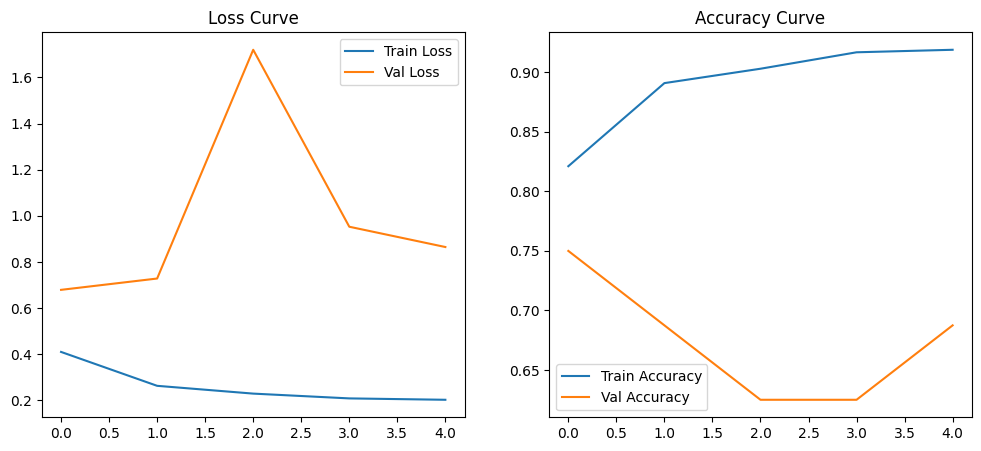

20/20 ━━━━━━━━━━━━━━━━━━━━ 361s 18s/step - accuracy: 0.8301 - loss: 0.4907

Final Test Accuracy: 83.01%


In [11]:
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# 1. Path Definition (Tomar screenshot onujayi)
train_dir = '/content/drive/MyDrive/problem 1/Archive/train'
test_dir = '/content/drive/MyDrive/problem 1/Archive/test'
val_dir = '/content/drive/MyDrive/problem 1/Archive/val'

# 2. Path Validation Check (Ei part ta check korbe path thik ache kina)
if not os.path.exists(train_dir):
    print(f"❌ ERROR: 'train' folder pawa jacche na ei path-e: {train_dir}")
    print("👉 KAJ: Bam pasher file menu theke 'train' folder khuje tar upor right-click kore 'Copy path' koro ar ekhane change koro.")
else:
    print("✅ Paths shob thik ache! Model building shuru hocche...\n")

    # 3. Data Generators
    train_datagen = ImageDataGenerator(rescale=1./255, shear_range=0.2, zoom_range=0.2, horizontal_flip=True)
    test_val_datagen = ImageDataGenerator(rescale=1./255)

    train_gen = train_datagen.flow_from_directory(train_dir, target_size=(150, 150), batch_size=32, class_mode='binary')
    val_gen = test_val_datagen.flow_from_directory(val_dir, target_size=(150, 150), batch_size=32, class_mode='binary')
    test_gen = test_val_datagen.flow_from_directory(test_dir, target_size=(150, 150), batch_size=32, class_mode='binary')

    # 4. Model Architecture
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
        MaxPooling2D(2, 2),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # 5. Training
    print("\nTraining shuru hocche. Ektu shomoy lagbe...")
    history = model.fit(train_gen, validation_data=val_gen, epochs=5) # 5 epochs fast korar jonno

    # 6. Graphs
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Loss Curve')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Accuracy Curve')
    plt.legend()
    plt.show()

    # 7. Final Evaluation
    loss, acc = model.evaluate(test_gen)
    print(f"\nFinal Test Accuracy: {acc*100:.2f}%")